In [1]:
import numpy as np
import pandas as pd


In [2]:
df = pd.read_csv("../data/final_prepared.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (15967, 13)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0  -0.536500 -0.083419           -1.810808     1.515710        2.062013   
1   1.252960 -1.249045           -0.850301     0.456168        0.288378   
2   0.834256 -0.885370            0.430374    -0.394993       -0.444883   
3  -0.401917  1.091532            0.030163    -0.047381        0.121728   
4  -1.339016  1.012270           -0.049879     1.483223        2.531014   

   population  households  median_income  ocean_proximity_INLAND  \
0    1.322515    2.106897      -0.744240               -0.693663   
1    0.516142    0.326958       0.793395               -0.693663   
2    0.599058   -0.450124      -0.283111               -0.693663   
3   -0.285674    0.127437      -1.377645                1.441622   
4    1.036412    2.613576      -0.290847               -0.693663   

   ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0               -0.017699                 -0.352419   
1          

In [3]:
# X = all columns except house price
# y = house price column only
X = df.drop(columns=["median_house_value"]).values
y = df["median_house_value"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (15967, 12)
y shape: (15967,)


In [4]:
class LinearRegressionScratch:
    
    def __init__(self):
        self.w = None   # one weight per feature, starts empty
        self.b = 0      # bias starts at zero
    
    def predict(self, X):
        # multiply each feature by its weight and add bias
        # Formula: y_hat = X*w + b
        return np.dot(X, self.w) + self.b
    
    def compute_loss(self, y, y_pred):
        # find average squared error between real and predicted prices
        # Formula: MSE = (1/m) * sum((y_pred - y)^2)
        m = len(y)
        loss = (1/m) * np.sum((y_pred - y) ** 2)
        return loss


In [5]:
# Create the model
model = LinearRegressionScratch()

# Set weights to zero for now
# Member 2 (Nushrath) will train these weights automatically
model.w = np.zeros(X.shape[1])
model.b = 0

# Predict using current (zero) weights
y_pred = model.predict(X)
print("First 5 predictions:", y_pred[:5])

# Check loss
loss = model.compute_loss(y, y_pred)
print("Initial Loss (MSE):", loss)
print("Loss is very high — expected! Weights are all zero.")
print("Model initialized successfully. Ready for training.")


First 5 predictions: [0. 0. 0. 0. 0.]
Initial Loss (MSE): 50275768758.0893
Loss is very high — expected! Weights are all zero.
Model initialized successfully. Ready for training.


In [6]:
class LinearRegressionScratch:
    
    def __init__(self):
        self.w = None
        self.b = 0
        self.loss_history = []
    
    def predict(self, X):
        # Formula: y_hat = X*w + b
        return np.dot(X, self.w) + self.b
    
    def compute_loss(self, y, y_pred):
        # MSE = (1/m) * sum((y_pred - y)^2)
        m = len(y)
        loss = (1/m) * np.sum((y_pred - y) ** 2)
        return loss
    
    def compute_gradients(self, X, y, y_pred):
        m = len(y)
        # how much each weight needs to change
        dw = (2/m) * np.dot(X.T, (y_pred - y))
        # how much bias needs to change
        db = (2/m) * np.sum(y_pred - y)
        return dw, db
    
    def train(self, X, y, lr, epochs):
        # initialize weights as zeros
        self.w = np.zeros(X.shape[1])
        self.b = 0
        self.loss_history = []
        
        for epoch in range(epochs):
            
            # Step 1: predict
            y_pred = self.predict(X)
            
            # Step 2: compute loss
            loss = self.compute_loss(y, y_pred)
            
            # Step 3: store loss
            self.loss_history.append(loss)
            
            # Step 4: compute gradients
            dw, db = self.compute_gradients(X, y, y_pred)
            
            # Step 5: update weights and bias
            self.w = self.w - lr * dw
            self.b = self.b - lr * db
            
            # print progress every 100 epochs
            if epoch % 100 == 0:
                print(f"Epoch {epoch} — Loss: {loss:.2f}")

In [7]:
# Create model
model = LinearRegressionScratch()

# Train on real housing data
model.train(X, y, lr=0.01, epochs=1000)

print("\nTraining Complete!")
print("Final Loss:", model.loss_history[-1])

Epoch 0 — Loss: 50275768758.09
Epoch 100 — Loss: 5760490256.41
Epoch 200 — Loss: 4895589495.28
Epoch 300 — Loss: 4797834190.46
Epoch 400 — Loss: 4741698523.80
Epoch 500 — Loss: 4702714454.05
Epoch 600 — Loss: 4674534339.46
Epoch 700 — Loss: 4653548103.21
Epoch 800 — Loss: 4637510407.40
Epoch 900 — Loss: 4624980188.21

Training Complete!
Final Loss: 4615096465.575833


In [8]:
#  Check trained weights
print("Trained Weights:", model.w)
print("Trained Bias:", model.b)
print("Total Epochs Trained:", len(model.loss_history))


Trained Weights: [-24489.48113461 -23740.96308377  14940.29671669  -8380.93619539
  27588.01282704 -42035.39637722  28234.50703949  61422.70739469
 -26201.868408     2966.19541125  -1282.627041     2929.10362795]
Trained Bias: 197550.94900052744
Total Epochs Trained: 1000


In [9]:
# Verify predictions improved
y_pred_trained = model.predict(X)

print("Real Prices:     ", y[:5])
print("Predicted Prices:", y_pred_trained[:5].round(2))

final_loss = model.compute_loss(y, y_pred_trained)
print("\nInitial Loss: 13404658468.24")
print("Final Loss:  ", round(final_loss, 2))


Real Prices:      [146400. 165800. 160600.  91400. 273400.]
Predicted Prices: [205443.55 241679.05 157789.03  78187.31 288693.31]

Initial Loss: 13404658468.24
Final Loss:   4615007086.45


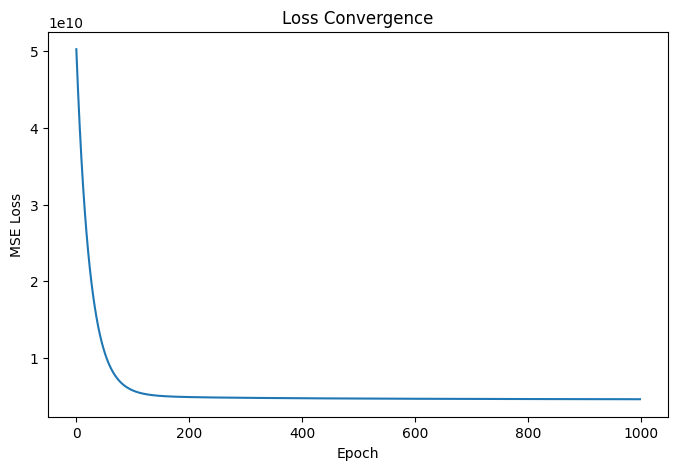

In [10]:
import matplotlib.pyplot as plt

# Plot training loss
plt.figure(figsize=(8,5))

plt.plot(model.loss_history)

plt.title("Loss Convergence")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.show()


In [11]:
# Predict using trained model
predictions = model.predict(X)

print("First 5 Predictions:")
print(predictions[:5])

print("\nFirst 5 Actual Prices:")
print(y[:5])

First 5 Predictions:
[205443.54602514 241679.04511515 157789.02706829  78187.31071606
 288693.3075544 ]

First 5 Actual Prices:
[146400. 165800. 160600.  91400. 273400.]


In [12]:
#add early stopping
class LinearRegressionScratch:
    
    def _init_(self):
        self.w = None
        self.b = 0
        self.loss_history = []
    
    def predict(self, X):
        # Formula: y_hat = X*w + b
        return np.dot(X, self.w) + self.b
    
    def compute_loss(self, y, y_pred):
        # MSE = (1/m) * sum((y_pred - y)^2)
        m = len(y)
        loss = (1/m) * np.sum((y_pred - y) ** 2)
        return loss
    
    def compute_gradients(self, X, y, y_pred):
        m = len(y)
        dw = (2/m) * np.dot(X.T, (y_pred - y))
        db = (2/m) * np.sum(y_pred - y)
        return dw, db
    
    def train(self, X, y, lr=0.01, epochs=1000, patience=10):
        # lr       → learning rate
        # epochs   → total training loops
        # patience → wait before early stopping
        
        self.w = np.zeros(X.shape[1])
        self.b = 0
        self.loss_history = []
        
        # early stopping variables
        best_loss = float('inf')
        no_improve_count = 0
        
        for epoch in range(epochs):
            
            # Step 1: predict
            y_pred = self.predict(X)
            
            # Step 2: compute loss
            loss = self.compute_loss(y, y_pred)
            
            # Step 3: store loss
            self.loss_history.append(loss)
            
            # Step 4: compute gradients
            dw, db = self.compute_gradients(X, y, y_pred)
            
            # Step 5: update weights
            self.w = self.w - lr * dw
            self.b = self.b - lr * db
            
            # Step 6: check improvement
            if loss < best_loss:
                best_loss = loss
                no_improve_count = 0
            else:
                no_improve_count += 1
            
            # Step 7: early stopping
            if no_improve_count >= patience:
                print(f"Early stopping at Epoch {epoch}")
                print(f"Loss did not improve for {patience} epochs")
                break
            
            # print progress
            if epoch % 100 == 0:
                print(f"Epoch {epoch} — Loss: {loss:.2f}")

In [13]:
#train with early stopping
# Create model
model = LinearRegressionScratch()

# Train model
model.train(X, y, lr=0.01, epochs=1000, patience=10)

print("\nTraining Complete!")
print("Total epochs ran:", len(model.loss_history))
print("Final Loss:", model.loss_history[-1])

Epoch 0 — Loss: 50275768758.09
Epoch 100 — Loss: 5760490256.41
Epoch 200 — Loss: 4895589495.28
Epoch 300 — Loss: 4797834190.46
Epoch 400 — Loss: 4741698523.80
Epoch 500 — Loss: 4702714454.05
Epoch 600 — Loss: 4674534339.46
Epoch 700 — Loss: 4653548103.21
Epoch 800 — Loss: 4637510407.40
Epoch 900 — Loss: 4624980188.21

Training Complete!
Total epochs ran: 1000
Final Loss: 4615096465.575833


In [14]:
#check loss history
print("First 5 loss values:", model.loss_history[:5])
print("Last 5 loss values: ", model.loss_history[-5:])
print("Total loss values tracked:", len(model.loss_history))

First 5 loss values: [50275768758.0893, 48399830383.73543, 46604461345.16186, 44885960782.2148, 43240823485.727715]
Last 5 loss values:  [4615455889.544629, 4615365746.372456, 4615275795.008333, 4615186034.919682, 4615096465.575833]
Total loss values tracked: 1000


In [15]:
#Verify predictions
y_pred_trained = model.predict(X)

print("Real Prices:     ", y[:5])
print("Predicted Prices:", y_pred_trained[:5].round(2))

final_loss = model.compute_loss(y, y_pred_trained)

print("\nInitial Loss: 13404658468.24")
print("Final Loss:  ", round(final_loss, 2))

Real Prices:      [146400. 165800. 160600.  91400. 273400.]
Predicted Prices: [205443.55 241679.05 157789.03  78187.31 288693.31]

Initial Loss: 13404658468.24
Final Loss:   4615007086.45


In [17]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


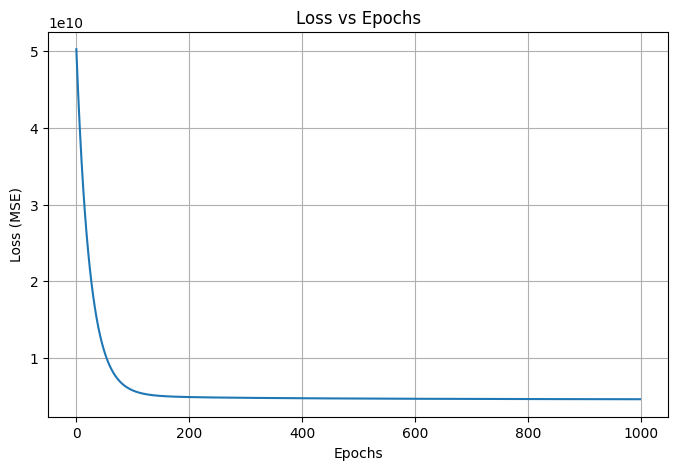

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(model.loss_history)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.grid(True)
plt.show()


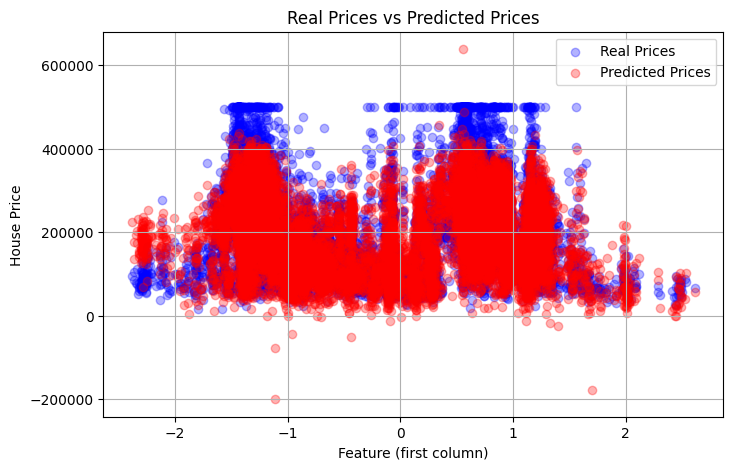

In [19]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], y, color="blue", alpha=0.3, label="Real Prices")
plt.scatter(X[:, 0], y_pred_trained, color="red", alpha=0.3, label="Predicted Prices")
plt.title("Real Prices vs Predicted Prices")
plt.xlabel("Feature (first column)")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
sklearn_model = LinearRegression()
sklearn_model.fit(X, y)
y_pred_sklearn = sklearn_model.predict(X)

print("sklearn model trained successfully!")
print("First 5 sklearn predictions:", y_pred_sklearn[:5].round(2))
